# SwanTeleco

In [27]:
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement sklearn==1.3.0 (from versions: 0.0, 0.0.post1, 0.0.post2, 0.0.post4, 0.0.post5, 0.0.post7, 0.0.post9, 0.0.post10, 0.0.post11, 0.0.post12)
ERROR: No matching distribution found for sklearn==1.3.0


In [28]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import ydf

from sklearn import metrics
from time import time

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

## EDA

In [29]:
data = pd.read_csv('ProjectData.csv')

data.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,Competitor had better devices


In [30]:
#convert all column names to snake case
data.columns = data.columns.to_series().apply(lambda x: "_".join(x.split()).lower())
data.columns

Index(['customerid', 'count', 'country', 'state', 'city', 'zip_code',
       'lat_long', 'latitude', 'longitude', 'gender', 'senior_citizen',
       'partner', 'dependents', 'tenure_months', 'phone_service',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method',
       'monthly_charges', 'total_charges', 'churn_label', 'churn_value',
       'churn_reason'],
      dtype='object')

In [31]:
# check columns for missing values and unique values (where data is not numerical)
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerid         7043 non-null   object 
 1   count              7043 non-null   int64  
 2   country            7043 non-null   object 
 3   state              7043 non-null   object 
 4   city               7043 non-null   object 
 5   zip_code           7043 non-null   int64  
 6   lat_long           7043 non-null   object 
 7   latitude           7043 non-null   float64
 8   longitude          7043 non-null   float64
 9   gender             7043 non-null   object 
 10  senior_citizen     7043 non-null   object 
 11  partner            7043 non-null   object 
 12  dependents         7043 non-null   object 
 13  tenure_months      7043 non-null   int64  
 14  phone_service      7043 non-null   object 
 15  multiple_lines     7043 non-null   object 
 16  internet_service   7043 

In [32]:
#check the numerical columns too:
data.describe()

,count,zip_code,latitude,longitude,tenure_months,monthly_charges,churn_value
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000


In [33]:
# How many customers churned or didnt churn?
print(f'This many customers churned: {len(data[data.churn_value==1])}' )
print(f'This many customers didn\'t churn: {len(data[data.churn_value==0])}' )
print(f'This is the percentage of churned customers:{len(data[data.churn_value==1])/len(data)*100}')

This many customers churned: 1869
This many customers didn't churn: 5174
This is the percentage of churned customers:26.536987079369588


### Columns to remove: check the data in columns

In [34]:
for column in data.columns:
    print(f'{column} : {data[column].nunique()}')

customerid : 7043
count : 1
country : 1
state : 1
city : 1129
zip_code : 1652
lat_long : 1652
latitude : 1652
longitude : 1651
gender : 2
senior_citizen : 2
partner : 2
dependents : 2
tenure_months : 73
phone_service : 2
multiple_lines : 3
internet_service : 3
online_security : 3
online_backup : 3
device_protection : 3
tech_support : 3
streaming_tv : 3
streaming_movies : 3
contract : 3
paperless_billing : 2
payment_method : 4
monthly_charges : 1585
total_charges : 6531
churn_label : 2
churn_value : 2
churn_reason : 20


In [35]:
#columns that aren't numerical
categorical_columns = [column for column in data.columns if data[column].dtype == 'O']
for column in categorical_columns:
    print(f'{column} : {data[column].unique()}')


customerid : ['3668-QPYBK' '9237-HQITU' '9305-CDSKC' ... '2234-XADUH' '4801-JZAZL'
 '3186-AJIEK']
country : ['United States']
state : ['California']
city : ['Los Angeles' 'Beverly Hills' 'Huntington Park' ... 'Standish' 'Tulelake'
 'Olympic Valley']
lat_long : ['33.964131, -118.272783' '34.059281, -118.30742' '34.048013, -118.293953'
 ... '40.346634, -120.386422' '41.813521, -121.492666'
 '39.191797, -120.212401']
gender : ['Male' 'Female']
senior_citizen : ['No' 'Yes']
partner : ['No' 'Yes']
dependents : ['No' 'Yes']
phone_service : ['Yes' 'No']
multiple_lines : ['No' 'Yes' 'No phone service']
internet_service : ['DSL' 'Fiber optic' 'No']
online_security : ['Yes' 'No' 'No internet service']
online_backup : ['Yes' 'No' 'No internet service']
device_protection : ['No' 'Yes' 'No internet service']
tech_support : ['No' 'Yes' 'No internet service']
streaming_tv : ['No' 'Yes' 'No internet service']
streaming_movies : ['No' 'Yes' 'No internet service']
contract : ['Month-to-month' 'Two year'

As we can see, the count,country, state and lat_long columns can be removed as they either contain only one type of data, or have data that is repeated in other columns (we already have a latitude and longitude column).

In [52]:
#drop columns
cleaned = data.drop(['count', 'country', 'state', 'lat_long','churn_label','churn_reason'], axis=1)
cleaned.head()

,customerid,city,zip_code,latitude,longitude,gender,senior_citizen,partner,dependents,tenure_months,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value
0,3668-QPYBK,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,9237-HQITU,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,9305-CDSKC,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,7892-POOKP,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,0280-XJGEX,Los Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


<Axes: xlabel='payment_method', ylabel='monthly_charges'>

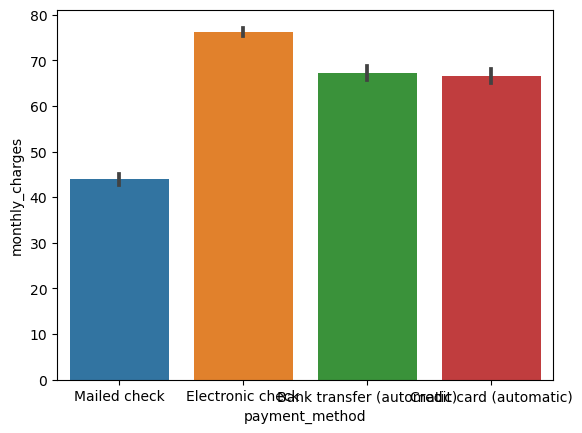

In [53]:


sns.barplot(y=cleaned.monthly_charges,x=cleaned.payment_method)

In [54]:
#sns.barplot(x=cleaned.payment_method,y=cleaned.senior_citizen)

## Feature Engineering

## Model Definition

In [56]:
features = list(cleaned.columns)
features.remove('churn_value')

y = cleaned['churn_value']
X = cleaned[features]

In [57]:
# We do the split, then bring back the targets because.. YDF doesn't even need the features split apart from the target! :o
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=1204, stratify=y)

X_train['churn_value'] = y_train # This is adding the label/target back to X train
X_test['churn_value'] = y_test   # Same for X_test

In [58]:
# Ready? Let's model - just as simple as sklearn
model = ydf.GradientBoostedTreesLearner(label="churn_value")
model = model.train(X_train)

Train model on 5634 examples
Model trained in 0:00:00.269417


In [59]:
model

In [60]:
model.evaluate(X_train)

Label \ Pred,0,1
0,3932,510
1,207,985


In [61]:
model.evaluate(X_test)

Label \ Pred,0,1
0,937,199
1,98,175


In [62]:
model.plot_tree()

In [63]:
model.describe()

## Fine tuning

In [64]:
# YDF has a built-in tuner to optimise your model.. very little to do for us!
tuner = ydf.RandomSearchTuner(num_trials=50)

In [65]:
# Fit the improved model
new_model = ydf.GradientBoostedTreesLearner(tuner=tuner, label='churn_value').train(X_train)

Train model on 5634 examples
Model trained in 0:00:00.174899


In [66]:
# Evaluate improved model on Train
new_model.evaluate(X_train)

Label \ Pred,0,1
0,3932,510
1,207,985


In [67]:
# And finally, on Test
new_model.evaluate(X_test)

Label \ Pred,0,1
0,937,199
1,98,175


In [68]:
new_model.describe()

trial,score,duration
0,-0.87718,0.173642
